In [10]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# --- Black-Scholes Formula ---
def black_scholes(S, K, T, r, sigma, option_type="call"):
    """
    S     : Current stock price
    K     : Strike price
    T     : Time to maturity (in years)
    r     : Risk-free interest rate
    sigma : Volatility
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    return price

# --- Greeks ---
def greeks(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        delta = norm.cdf(d1)
    else:
        delta = norm.cdf(d1) - 1

    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T) / 100

    return delta, gamma, vega

print("Functions loaded successfully!")

Functions loaded successfully!


In [11]:
# --- Static Test ---
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

print(f"Call Price: {black_scholes(S, K, T, r, sigma, 'call'):.2f}")
print(f"Put Price:  {black_scholes(S, K, T, r, sigma, 'put'):.2f}")

delta, gamma, vega = greeks(S, K, T, r, sigma, "call")
print(f"\nDelta : {delta:.4f}")
print(f"Gamma : {gamma:.4f}")
print(f"Vega  : {vega:.4f}")

Call Price: 10.45
Put Price:  5.57

Delta : 0.6368
Gamma : 0.0188
Vega  : 0.3752


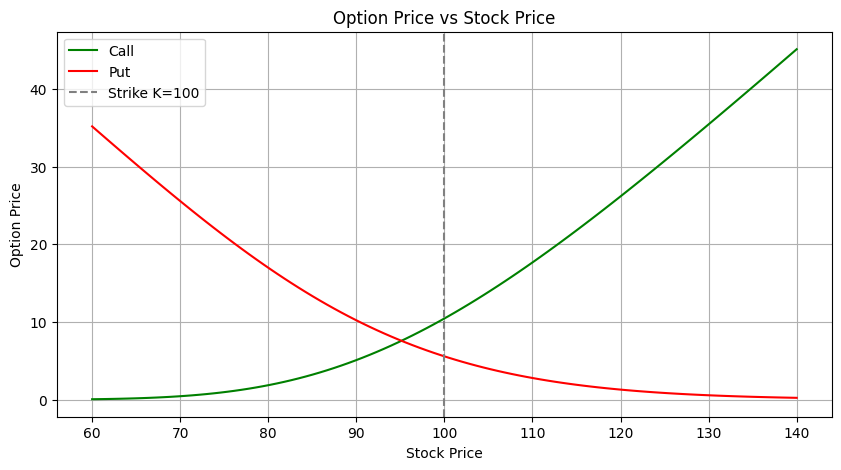

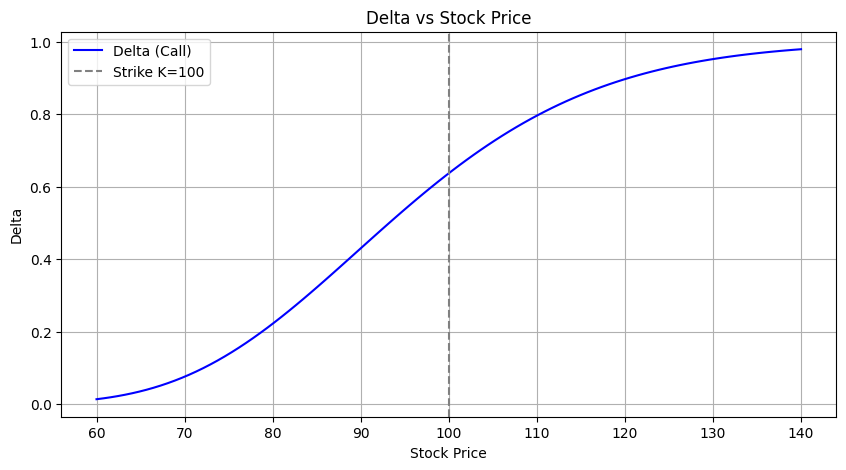

In [12]:
# --- Visualizations ---
stock_prices = np.linspace(60, 140, 100)
call_prices = [black_scholes(s, K, T, r, sigma, "call") for s in stock_prices]
put_prices  = [black_scholes(s, K, T, r, sigma, "put")  for s in stock_prices]

plt.figure(figsize=(10, 5))
plt.plot(stock_prices, call_prices, label="Call", color="green")
plt.plot(stock_prices, put_prices,  label="Put",  color="red")
plt.axvline(x=K, linestyle="--", color="gray", label="Strike K=100")
plt.title("Option Price vs Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Option Price")
plt.legend()
plt.grid(True)
plt.show()

deltas = [greeks(s, K, T, r, sigma, "call")[0] for s in stock_prices]
plt.figure(figsize=(10, 5))
plt.plot(stock_prices, deltas, label="Delta (Call)", color="blue")
plt.axvline(x=K, linestyle="--", color="gray", label="Strike K=100")
plt.title("Delta vs Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# --- Interactive Pricer ---
def interactive_pricer(S, K, T, r, sigma):
    call = black_scholes(S, K, T, r, sigma, "call")
    put  = black_scholes(S, K, T, r, sigma, "put")
    delta, gamma, vega = greeks(S, K, T, r, sigma, "call")

    print(f"=" * 45)
    print(f"  CALL Price : ${call:.2f}    PUT Price : ${put:.2f}")
    print(f"=" * 45)
    print(f"  Delta : {delta:.4f}")
    print(f"  Gamma : {gamma:.4f}")
    print(f"  Vega  : {vega:.4f}")
    print(f"=" * 45)

    stock_range = np.linspace(S * 0.5, S * 1.5, 100)
    call_prices = [black_scholes(s, K, T, r, sigma, "call") for s in stock_range]
    put_prices  = [black_scholes(s, K, T, r, sigma, "put")  for s in stock_range]

    plt.figure(figsize=(10, 4))
    plt.plot(stock_range, call_prices, label="Call", color="green")
    plt.plot(stock_range, put_prices,  label="Put",  color="red")
    plt.axvline(x=K, linestyle="--", color="gray", label=f"Strike K={K}")
    plt.axvline(x=S, linestyle="--", color="blue", label=f"Current S={S}")
    plt.title("Option Price vs Stock Price")
    plt.xlabel("Stock Price")
    plt.ylabel("Option Price")
    plt.legend()
    plt.grid(True)
    plt.show()

widgets.interact(
    interactive_pricer,
    S=widgets.FloatSlider(value=100, min=50,  max=200, step=1,    description="Stock (S)"),
    K=widgets.FloatSlider(value=100, min=50,  max=200, step=1,    description="Strike (K)"),
    T=widgets.FloatSlider(value=1,   min=0.1, max=3,   step=0.1,  description="Maturity (T)"),
    r=widgets.FloatSlider(value=0.05,min=0,   max=0.2, step=0.01, description="Rate (r)"),
    sigma=widgets.FloatSlider(value=0.2, min=0.05, max=0.8, step=0.01, description="Volatility"),
)

interactive(children=(FloatSlider(value=100.0, description='Stock (S)', max=200.0, min=50.0, step=1.0), FloatS…

<function __main__.interactive_pricer(S, K, T, r, sigma)>